<a href="https://colab.research.google.com/github/Rohit-VN/PyTorch-Practice/blob/main/01_PyTorch_Workflow_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
# Linear Regression
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02
x = torch.arange(start,end,step).unsqueeze(dim = 1)
y = x * weight + bias
x[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
train_split = int(0.8 * len(x))
x_train = x[:train_split]
y_train = y[:train_split]
x_test = x[train_split:]
y_test = y[train_split:]
len(x_train),len(y_train),len(x_test),len(y_test)


(40, 40, 10, 10)

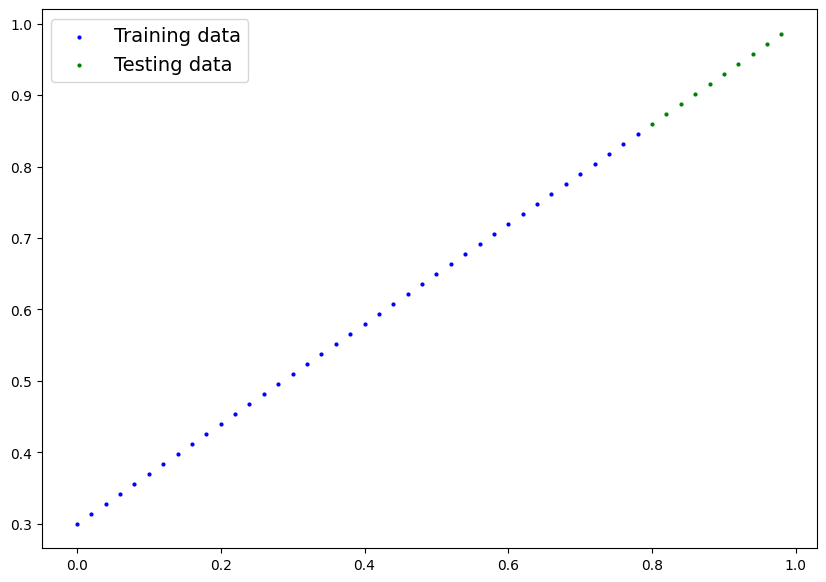

In [4]:
def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

plot_predictions();

In [5]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,dtype = torch.float),requires_grad = True)
    self.bias = nn.Parameter(torch.randn(1,dtype = torch.float),requires_grad = True)
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias

In [6]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
list(model_0.parameters())
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

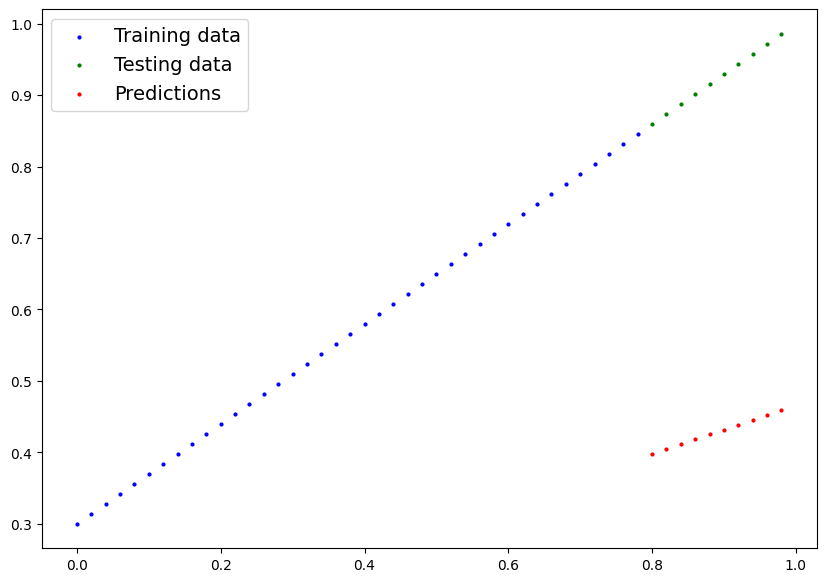

In [7]:
# Predictions
with torch.inference_mode():
  y_preds = model_0(x_test)
plot_predictions(predictions=y_preds)
y_test - y_preds


In [8]:
loss_func = torch.nn.L1Loss()
optimizer = torch.optim.SGD(params = model_0.parameters(),lr = 0.01)

torch.manual_seed(42)
epochs = 1000
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_0.train()
  y_pred = model_0(x_train)
  loss = loss_func(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()

  with torch.inference_mode():
    test_pred = model_0(x_test)
    test_loss = loss_func(test_pred,y_test.type(torch.float))

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
print(model_0.state_dict())


Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

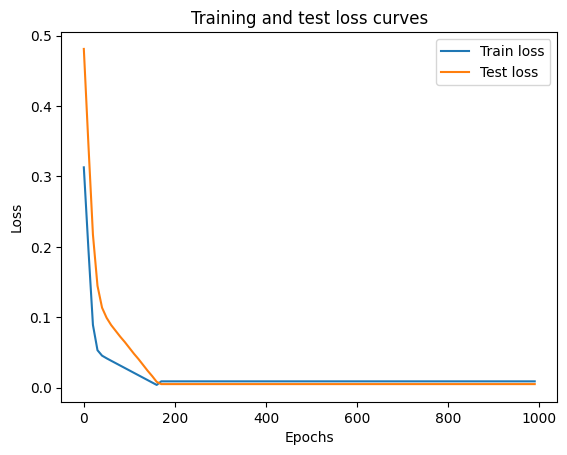

In [9]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();
model_0.state_dict()

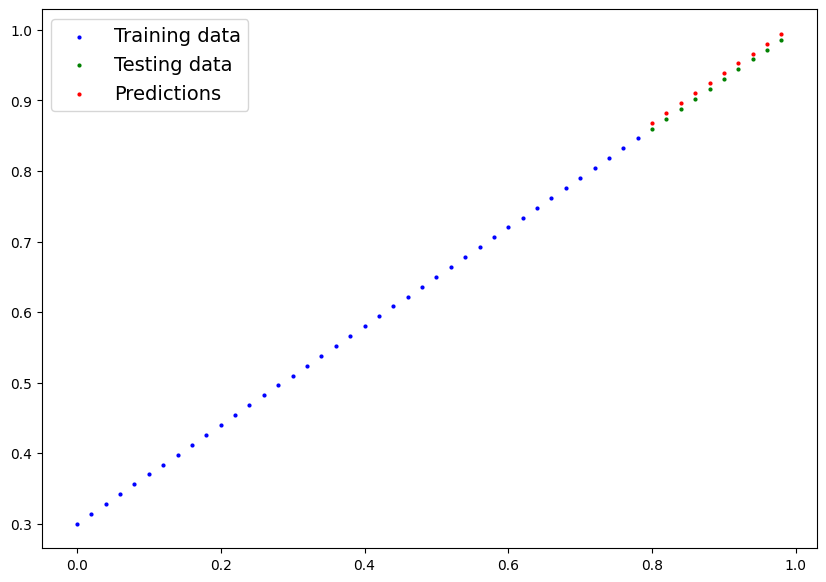

In [10]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(x_test)
  plot_predictions(predictions = y_preds)

In [11]:
# Saving the model
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True , exist_ok = True)
MODEL_NAME = "model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
print(f"Saving model to path: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),f = MODEL_SAVE_PATH)


Saving model to path: models/model_0.pth


In [12]:
# Loading the model
model_0_load = LinearRegressionModel()
model_0_load.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
model_0_load.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])


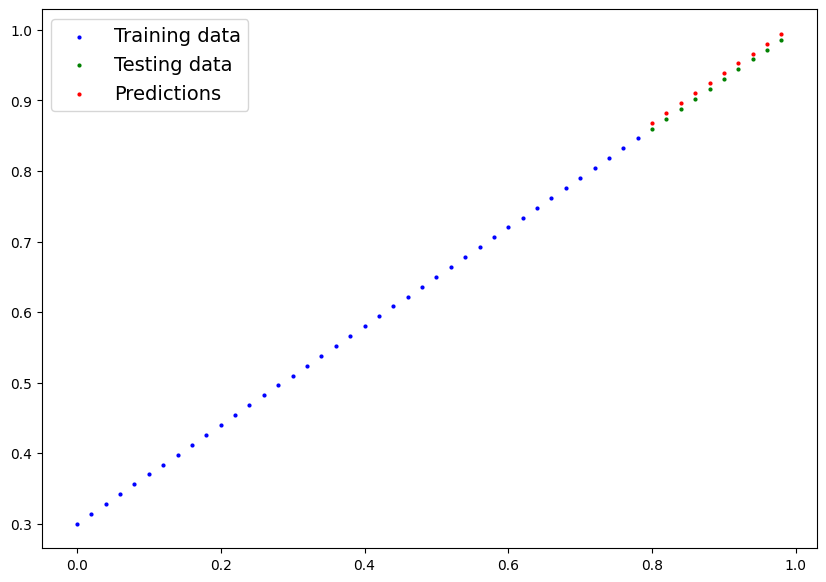

In [13]:
model_0_load.eval()
with torch.inference_mode():
  load_model_preds = model_0_load(x_test)
  plot_predictions(predictions=load_model_preds)
  print(y_preds == load_model_preds)

In [14]:
#Revision
import torch
from torch import nn
import matplotlib.pyplot as plt

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"The device used is {device}")

The device used is cuda


In [16]:
weight = 0.7
bias  = 0.3
x = torch.arange(0,1,0.02).unsqueeze(dim = 1)
y = weight * x + bias
print(x[:10],y[:10])

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


In [17]:
x_train = x[:int(0.8 * len(x))]
x_test = x[int(0.8 * len(x)):]
y_train = y[:int(0.8 * len(x))]
y_test = y[int(0.8 * len(x)):]
print(len(x_train),len(y_train),len(x_test),len(y_test))

40 40 10 10


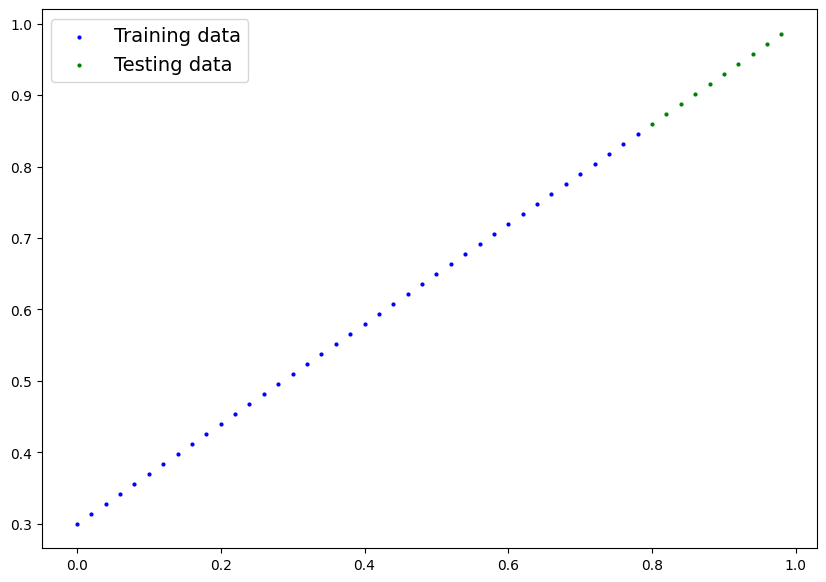

In [18]:
plot_predictions(x_train, y_train, x_test, y_test)

In [19]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features = 1 , out_features = 1)
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [20]:
torch.manual_seed(42)
model_1 = LinearRegressionModel()
model_1.state_dict()
# Locate the devices where each parameter is stored
unique_devices = {param.device for param in model_1.parameters()}

print(f"Model parameters live on device(s): {unique_devices}")
model_1.to(device)
unique_devices = {param.device for param in model_1.parameters()}

print(f"Model parameters live on device(s): {unique_devices}")


Model parameters live on device(s): {device(type='cpu')}
Model parameters live on device(s): {device(type='cuda', index=0)}


In [21]:
new_loss_func = torch.nn.L1Loss()
new_optim = torch.optim.SGD(params = model_1.parameters(),lr = 0.01)
x_test =x_test.to(device)
x_train = x_train.to(device)
y_test = y_test.to(device)
y_train = y_train.to(device)

epochs = 1000
epoch_count = []
train_loss_values = []
test_loss_values = []
model_1.train()
for epoch in range(epochs):
  model_1.train()
  y_pred = model_1(x_train)
  loss = new_loss_func(y_pred,y_train)
  new_optim.zero_grad()
  loss.backward()
  new_optim.step()
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(x_test)
    test_loss = new_loss_func(test_pred,y_test)
    if epoch % 100 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss.detach().cpu().numpy())
      test_loss_values.append(test_loss.detach().cpu().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
print(model_1.state_dict())


Epoch: 0 | MAE Train Loss: 0.5551779270172119 | MAE Test Loss: 0.5739762187004089 
Epoch: 100 | MAE Train Loss: 0.006215683650225401 | MAE Test Loss: 0.014086711220443249 
Epoch: 200 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 300 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 400 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 500 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 600 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 700 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 800 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
Epoch: 900 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801801018416882 
OrderedDict({'linear_layer.weight': tensor([[0.6968]], device='cuda:0'), 'linear_layer.bias': tensor([0.3025

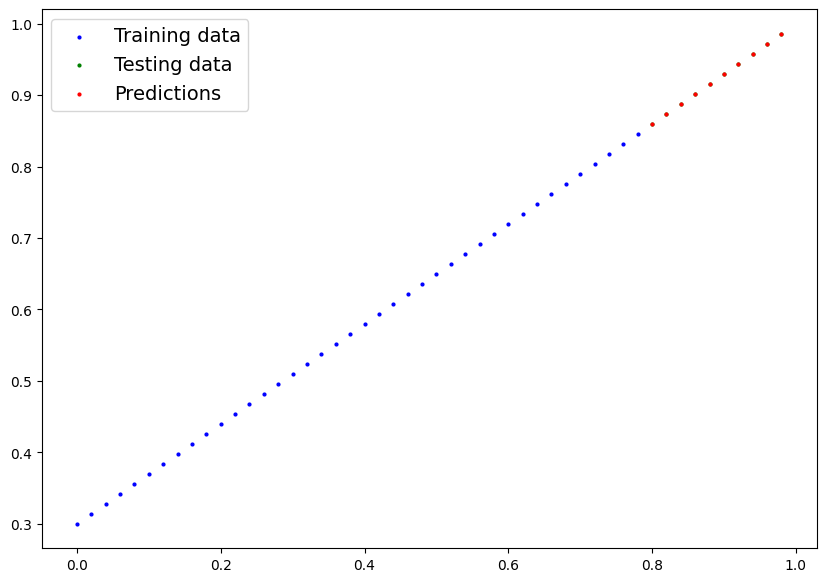

In [22]:
# Evaluation
model_1.eval()
with torch.inference_mode():
  test_pred = model_1(x_test)
  plot_predictions(predictions=test_pred.cpu())

In [23]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)
MODEL_NAME = "model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)
model_1_load = LinearRegressionModel()
model_1_load.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
model_1_load.to(device)
print(next(model_1_load.parameters()).device)

cuda:0


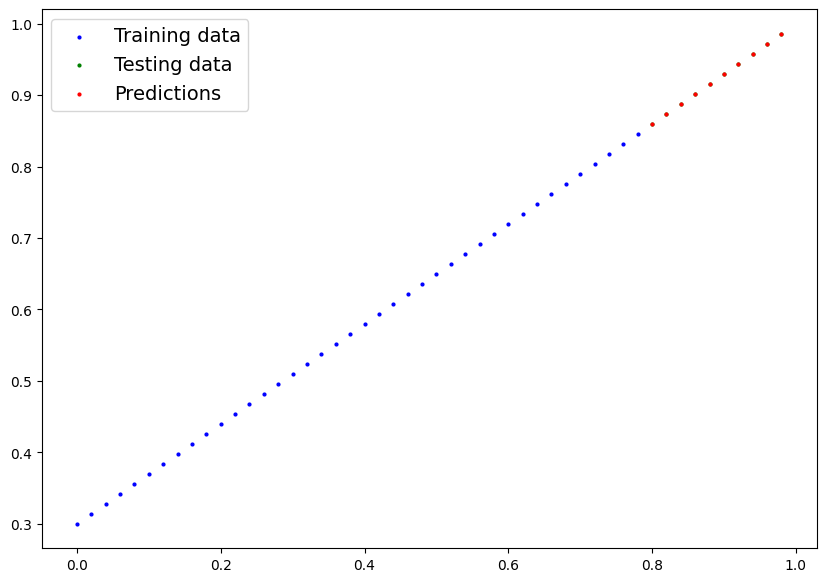

In [24]:
model_1_load.eval()
with torch.inference_mode():
  load_model_preds = model_1_load(x_test)
  plot_predictions(predictions=load_model_preds.cpu())


torch.float32


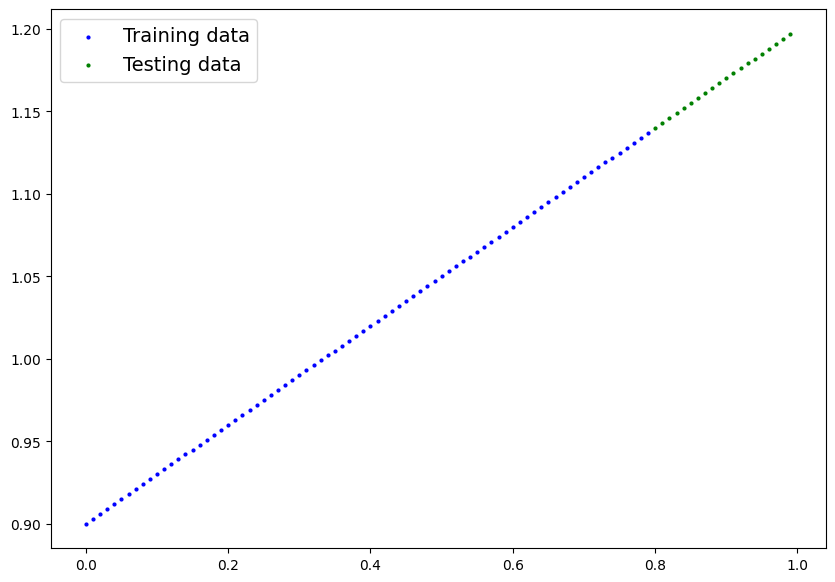

In [25]:
# Execises

"""1. Create a straight line dataset using the linear regression formula (weight * X + bias).
Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.
Split the data into 80% training, 20% testing.
Plot the training and testing data so it becomes visual."""
import torch
from torch import nn
import matplotlib.pyplot as plt

weight = 0.3
bias = 0.9
x = torch.arange(0,1,0.01).unsqueeze(dim = 1)
x = x.to(torch.float32)
y = weight * x + bias
if torch.cuda.is_available():
  device = 'cuda'
  x = x.to(device)
  y = y.to(device)

train_split = int(0.8 * len(x))
x_train = x[:train_split]
x_test = x[train_split:]
y_train = y[:train_split]
y_test = y[train_split:]
print(x_train.dtype)

def plot_predictions(train_data=x_train.cpu(),
                     train_labels=y_train.cpu(),
                     test_data=x_test.cpu(),
                     test_labels=y_test.cpu(),
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

plot_predictions();

In [26]:
"""2. Build a PyTorch model by subclassing nn.Module.
Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.
Implement the forward() method to compute the linear regression function you used to create the dataset in 1.
Once you've constructed the model, make an instance of it and check its state_dict().
Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can."""

class Pytorch_Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features = 1 , out_features = 1)
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [27]:
"""3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.
Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
Write a training loop to perform the appropriate training steps for 300 epochs.
The training loop should test the model on the test dataset every 20 epochs."""
torch.manual_seed(42)
exercise_model = Pytorch_Model()
exercise_model.to(torch.device('cuda'))
print(exercise_model.state_dict())
loss_func = nn.L1Loss()
optimizer = torch.optim.SGD(params = exercise_model.parameters(),lr = 0.01)
epoch_count = []
train_loss = []
test_loss = []

epochs = 300
for epoch in range(epochs):
  exercise_model.train()
  train_pred = exercise_model(x_train)
  Loss = loss_func(train_pred,y_train)
  optimizer.zero_grad()
  Loss.backward()
  optimizer.step()
  if epoch % 20 == 0:
    exercise_model.eval()
    with torch.inference_mode():
      test_pred = exercise_model(x_test)
      test_loss_value = loss_func(test_pred,y_test)
      epoch_count.append(epoch)
      train_loss.append(Loss.detach().cpu().numpy())
      test_loss.append(test_loss_value.detach().cpu().numpy())
      print(f" Epoch : {epoch} | Test Loss: {test_loss_value} | Train Loss: {Loss}")
print(exercise_model.state_dict())


OrderedDict({'linear_layer.weight': tensor([[0.7645]], device='cuda:0'), 'linear_layer.bias': tensor([0.8300], device='cuda:0')})
 Epoch : 0 | Test Loss: 0.33650314807891846 | Train Loss: 0.1275613158941269
 Epoch : 20 | Test Loss: 0.21840262413024902 | Train Loss: 0.08187223970890045
 Epoch : 40 | Test Loss: 0.17458660900592804 | Train Loss: 0.07207288593053818
 Epoch : 60 | Test Loss: 0.15310420095920563 | Train Loss: 0.06507987529039383
 Epoch : 80 | Test Loss: 0.1367770880460739 | Train Loss: 0.05822876840829849
 Epoch : 100 | Test Loss: 0.12079393863677979 | Train Loss: 0.05137667804956436
 Epoch : 120 | Test Loss: 0.10446684807538986 | Train Loss: 0.04452557489275932
 Epoch : 140 | Test Loss: 0.08813951909542084 | Train Loss: 0.0376744270324707
 Epoch : 160 | Test Loss: 0.0721558928489685 | Train Loss: 0.03082224726676941
 Epoch : 180 | Test Loss: 0.055828340351581573 | Train Loss: 0.02397105097770691
 Epoch : 200 | Test Loss: 0.03950077295303345 | Train Loss: 0.01711984723806381

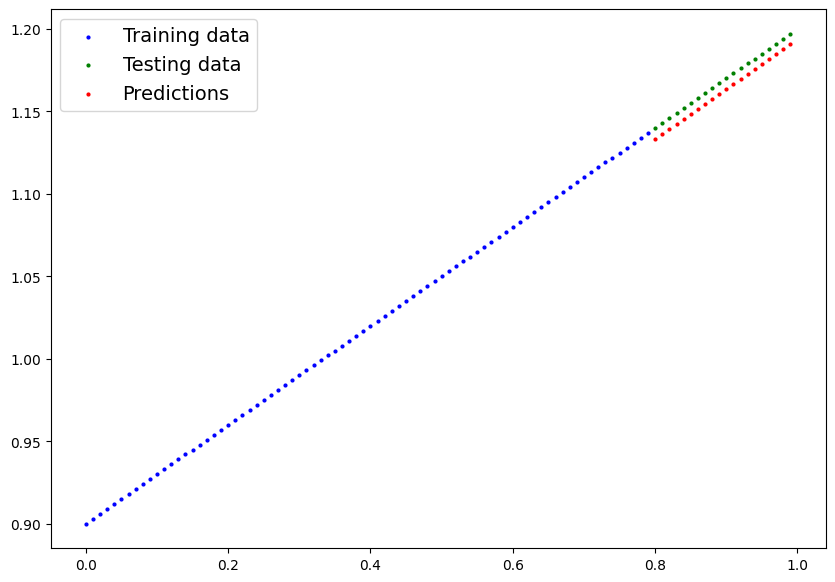

In [28]:
"""4. Make predictions with the trained model on the test data.
Visualize these predictions against the original training and testing data
(note: you may need to make sure the predictions are not on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot)."""
exercise_model.eval()
with torch.inference_mode():
  test_pred = exercise_model(x_test)
  plot_predictions(predictions=test_pred.cpu())

In [30]:
"""5. Save your trained model's state_dict() to file.
Create a new instance of your model class you made in 2. and load in the state_dict() you just saved to it.
Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4."""
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok=True)
MODEL_NAME = "exercise_model.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
torch.save(obj = exercise_model.state_dict(),f = MODEL_SAVE_PATH)

new_exercise_model = Pytorch_Model()
new_exercise_model.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
new_exercise_model.to(torch.device('cuda'))
print(new_exercise_model.state_dict())

with torch.inference_mode():
  test_pred = exercise_model(x_test)
  test_pred_new = new_exercise_model(x_test)
  print(test_pred == test_pred_new)



OrderedDict({'linear_layer.weight': tensor([[0.3028]], device='cuda:0'), 'linear_layer.bias': tensor([0.8910], device='cuda:0')})
tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')
